# AML s26 - SVM

A **kernel** implicitly maps data into a higher-dimensional feature space, allowing the SVM to find a linear separator there — which corresponds to a non-linear boundary in the original space

### Load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

### Generate data sets (1. **Simple**, 2. **Concentric circles**, and 3. **Interleaved "moons"**)

In [3]:
np.random.seed(7)

# ── Dataset 1: linearly separable ─────────────────────────────────
n = 60
X_lin = np.r_[np.random.randn(n//2, 2) + [-2, -1],
              np.random.randn(n//2, 2) + [ 2,  1]]
y_lin = np.array([-1]*(n//2) + [1]*(n//2))

# ── Dataset 2: concentric circles ─────────────────────────────────
X_cir, y_cir = make_circles(n_samples=n, noise=0.12, factor=0.45, random_state=7)
y_cir = np.where(y_cir == 0, -1, 1)

# ── Dataset 3: interleaved moons ──────────────────────────────────
X_moo, y_moo = make_moons(n_samples=n, noise=0.18, random_state=7)
y_moo = np.where(y_moo == 0, -1, 1)

datasets = [
    (X_lin, y_lin, 'Simple'),
    (X_cir, y_cir, 'Circles'),
    (X_moo, y_moo, 'Moons'),
]

print("Datasets ready:", [d[2] for d in datasets])

Datasets ready: ['Simple', 'Circles', 'Moons']


### Define kernels 


In [4]:
kernels = [
    ('Linear',      dict(kernel='linear',  C=1)),
    ('Polynomial',  dict(kernel='poly',    C=1, degree=3, coef0=1)),
    ('RBF',         dict(kernel='rbf',     C=1, gamma='scale')),
]

### Show decision boundaries for all kernels and all data sets

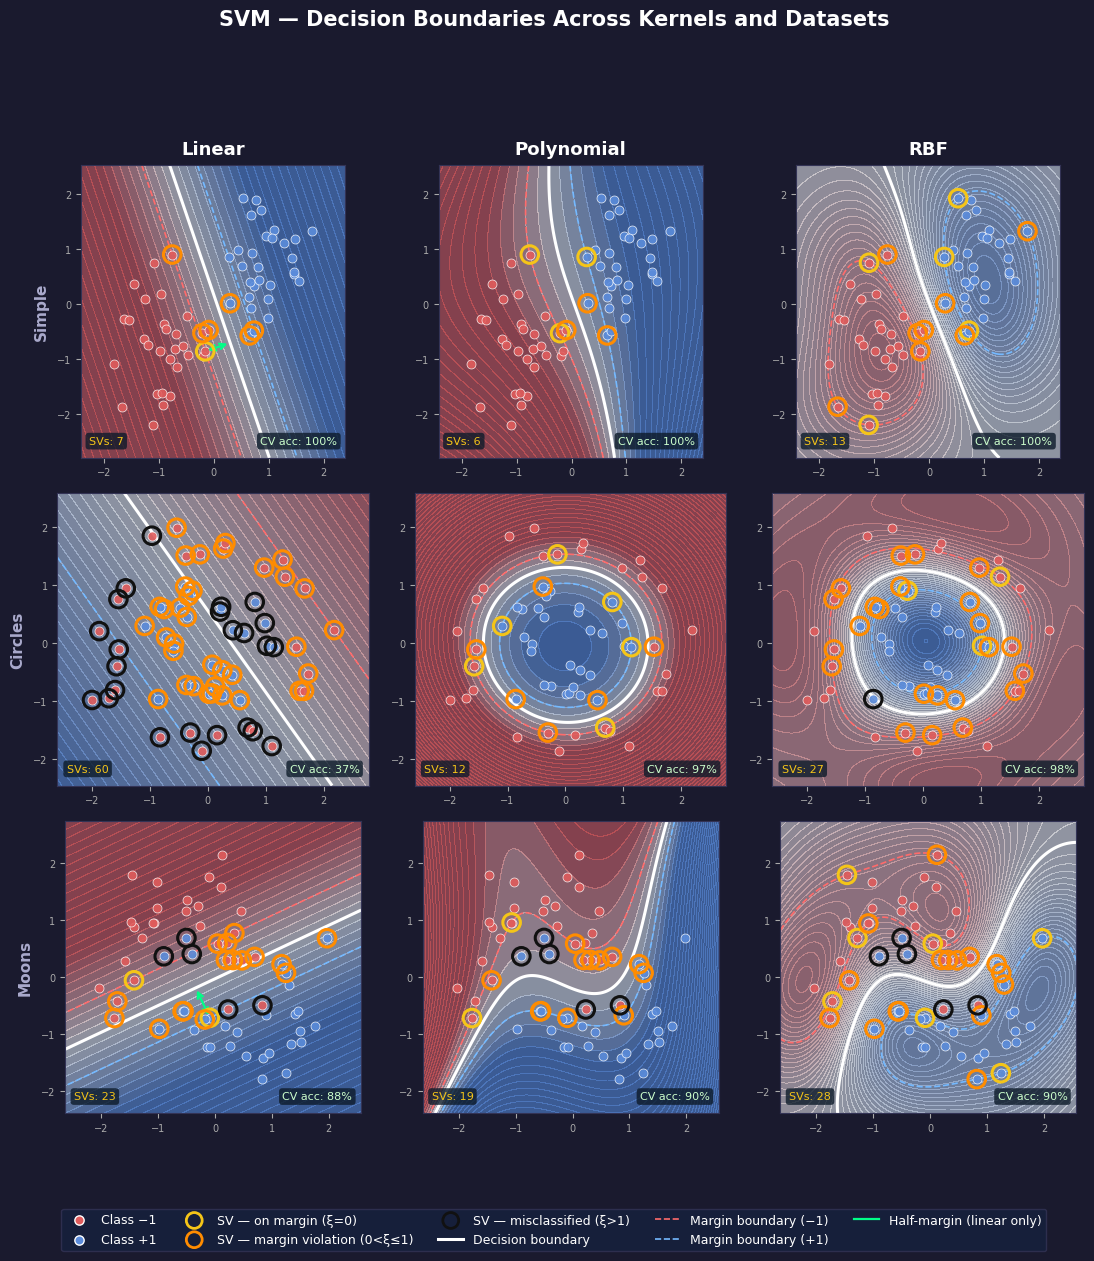

In [5]:
# ── colour palette ─────────────────────────────────────────────────
COL_NEG   = '#e05c5c'   # class -1
COL_POS   = '#5b8cdb'   # class +1
COL_SV_OK = '#f5c518'   # on-margin SV
COL_SV_VI = '#ff8c00'   # margin-violation SV
COL_SV_ER = '#111111'   # misclassified SV

cmap_bg = mcolors.LinearSegmentedColormap.from_list('svm_bg', [COL_NEG, '#f5f5f5', COL_POS])

n_rows = len(datasets)
n_cols = len(kernels)

fig, axes = plt.subplots(n_rows, n_cols,figsize=(4.5 * n_cols, 4.0 * n_rows),  constrained_layout=False)
fig.patch.set_facecolor('#1a1a2e')

for row, (X, y, ds_name) in enumerate(datasets):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    pad = 0.6
    x1_min, x1_max = Xs[:, 0].min() - pad, Xs[:, 0].max() + pad
    x2_min, x2_max = Xs[:, 1].min() - pad, Xs[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 350),np.linspace(x2_min, x2_max, 350))

    for col, (k_name, k_params) in enumerate(kernels):
        ax = axes[row, col]
        ax.set_facecolor('#16213e')

        clf = SVC(**k_params)
        clf.fit(Xs, y)
        cv_acc = cross_val_score(clf, Xs, y, cv=5).mean()

        # decision surface
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=50, cmap=cmap_bg, alpha=0.55, vmin=-2.5, vmax=2.5)

        # decision boundary + margin lines
        cs = ax.contour(xx, yy, Z, levels=[-1, 0, 1],  linestyles=['--', '-', '--'], colors=['#ff6b6b', '#ffffff', '#74b9ff'], linewidths=[1.2, 2.2, 1.2])

        # ── support vector classification by slack ─────────────────
        w_norm = np.linalg.norm(clf.coef_[0]) if k_name == 'Linear' else None
        sv_scores = y[clf.support_] * clf.decision_function(clf.support_vectors_)
        sv_xi     = np.maximum(0, 1 - sv_scores)
        mask_ok  = sv_xi <= 1e-6
        mask_vio = (sv_xi > 1e-6) & (sv_xi <= 1)
        mask_err = sv_xi > 1

        # ── data points ───────────────────────────────────────────
        for cls, col_pt in [(-1, COL_NEG), (1, COL_POS)]:
            m = y == cls
            ax.scatter(*Xs[m].T, color=col_pt, edgecolors='white',s=42, zorder=3, linewidths=0.5, alpha=0.9)

        # ── support vectors ───────────────────────────────────────
        sv = clf.support_vectors_
        for mask, ec, lw in [  (mask_ok,  COL_SV_OK, 2.2), (mask_vio, COL_SV_VI, 2.2), (mask_err, COL_SV_ER, 2.2)   ]:
            if mask.any():
                ax.scatter(*sv[mask].T, s=160, facecolors='none',   edgecolors=ec, linewidths=lw, zorder=4)

        # ── margin arrow for linear kernel only ───────────────────
        if k_name == 'Linear' and w_norm is not None and mask_ok.any():
            w = clf.coef_[0]
            b = clf.intercept_[0]
            centre = np.array([(x1_min+x1_max)/2, (x2_min+x2_max)/2])
            cands  = sv[mask_ok]
            anchor = cands[np.argmin(np.linalg.norm(cands - centre, axis=1))]
            foot   = anchor - (np.dot(w, anchor) + b) / np.dot(w, w) * w
            ax.annotate('', xy=foot, xytext=anchor, arrowprops=dict(arrowstyle='<->', color='#00ff88', lw=1.6,  mutation_scale=10))

        # ─ titles and labels ──────────────────────────────────
        n_sv = clf.support_vectors_.shape[0]
        ax.set_aspect('equal')
        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(x2_min, x2_max)
        ax.tick_params(colors='#aaaaaa', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333355')

        # column headers (kernel names) — top row only
        if row == 0:
            ax.set_title(k_name, fontsize=13, fontweight='bold', color='white', pad=8)

        # row labels (dataset names) — left column only
        if col == 0:
            ax.set_ylabel(ds_name, fontsize=11, fontweight='bold', color='#aaaacc', labelpad=6)

        # accuracy badge
        ax.text(0.97, 0.04, f'CV acc: {cv_acc:.0%}', transform=ax.transAxes, ha='right', va='bottom',  fontsize=8, color='#ccffcc',  bbox=dict(boxstyle='round,pad=0.3', fc='#0d1b2a', ec='none', alpha=0.8))

        # SV count badge
        ax.text(0.03, 0.04, f'SVs: {n_sv}',  transform=ax.transAxes, ha='left', va='bottom', fontsize=8, color='#f5c518',bbox=dict(boxstyle='round,pad=0.3', fc='#0d1b2a', ec='none', alpha=0.8))

# ─--─ shared legend ─────────────────────────────────────────────────
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

legend_handles = [
    plt.scatter([], [], color=COL_NEG, edgecolors='white', s=45, label='Class −1'),
    plt.scatter([], [], color=COL_POS, edgecolors='white', s=45, label='Class +1'),
    plt.scatter([], [], s=130, facecolors='none', edgecolors=COL_SV_OK, linewidths=2, label='SV — on margin (ξ=0)'),
    plt.scatter([], [], s=130, facecolors='none', edgecolors=COL_SV_VI, linewidths=2, label='SV — margin violation (0<ξ≤1)'),
    plt.scatter([], [], s=130, facecolors='none', edgecolors=COL_SV_ER, linewidths=2, label='SV — misclassified (ξ>1)'),
    Line2D([0],[0], color='#ffffff', lw=2.2, label='Decision boundary'),
    Line2D([0],[0], color='#ff6b6b', lw=1.2, ls='--', label='Margin boundary (−1)'),
    Line2D([0],[0], color='#74b9ff', lw=1.2, ls='--', label='Margin boundary (+1)'),
    Line2D([0],[0], color='#00ff88', lw=1.6, label='Half-margin (linear only)'),
]

fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=9, frameon=True, facecolor='#16213e', edgecolor='#333355', labelcolor='white', bbox_to_anchor=(0.5, -0.03))

fig.suptitle('SVM — Decision Boundaries Across Kernels and Datasets', fontsize=15, fontweight='bold', color='white', y=1.01)

plt.subplots_adjust(wspace=0.08, hspace=0.12, bottom=0.09)
plt.show()